# DALES LiDAR Processing Pipeline v4

## Nguyên tắc

DALES là dataset **đã sạch**, được chuẩn bị cho semantic segmentation → chỉ làm những gì cần thiết để biến dữ liệu thành format phù hợp cho 2 model, **không preprocessing quá mức**.

### Những gì KHÔNG làm (và tại sao)

| Bỏ | Lý do |
|-----|-------|
| ❌ SOR | DALES đã sạch. SOR với std=2.5 vẫn có thể mất power lines, poles, fences |
| ❌ Z outlier removal | DALES không có lỗi sensor bay → không cần lọc z |
| ❌ Voxel downsample cho Semantic | Majority voting mất class nhỏ |
| ❌ Duplicate padding | Block < ngưỡng → bỏ, không pad |

### Pipeline

```
             DALES .las
               │
        Read XYZ + labels
               │
         NaN / Inf check
               │
         Remove class 0
               │
        20m × 20m blocks
               │
        ┌──────┴──────┐
        │             │
        ▼             ▼
     PoinTr        Semantic
        │             │
   ≥ 8192 raw?    ≥ 2048 raw?
        │             │
   FPS → 8192      FPS → 2048
        │             │
   voxel 0.15m     labels 2048
        │             │
   sparse → 2048   normalize
        │             │
   normalize          ▼
        │          .npy
        ▼
      .npy
```

## Output format

| Dataset | File | Nội dung |
|---------|------|----------|
| PoinTr | `partial (2048, 3)` + `complete (8192, 3)` | Normalized, cùng transform |
| Semantic | `points (2048, 3)` + `labels (2048,)` | Labels gốc 1-8, shift -1 khi train |

## Cell 1 — Config

- `NUM_COMPLETE = 8192`: Dense GT cho PoinTr
- `NUM_PARTIAL = 2048`: Sparse input cho PoinTr
- `NUM_SEMANTIC = 2048`: Số điểm cố định cho Point Transformer
- `VOXEL_PREFILTER = 0.15`: Chỉ dùng cho PoinTr partial (sparse simulation)

### Labels
- File `.npy` lưu DALES gốc = **1..8**
- Khi train: `labels = labels - 1` → **0..7** cho CrossEntropyLoss
- KHÔNG sửa label trong preprocessing

In [16]:
import os
import glob
import laspy
import numpy as np
import open3d as o3d
from pathlib import Path

# ── Đường dẫn ──
DALES_LAS_DIR = r"D:\AIP\data\lidar\dales\dales_semantic_segmentation_las\dales_las"
OUTPUT_ROOT   = r"D:\AIP\data_processed"
POINTR_OUT    = os.path.join(OUTPUT_ROOT, "pointr")
SEMANTIC_OUT  = os.path.join(OUTPUT_ROOT, "semantic")

# ── Tham số ──
BLOCK_SIZE      = 20.0
NUM_COMPLETE    = 8192      # PoinTr dense GT
NUM_PARTIAL     = 2048      # PoinTr sparse input
NUM_SEMANTIC    = 2048      # Point Transformer — fixed size
VOXEL_PREFILTER = 0.15      # Chỉ cho PoinTr partial

# ── 8 lớp DALES gốc ──
DALES_CLASS_NAMES = {
    0: "Unclassified", 1: "Ground", 2: "Vegetation", 3: "Cars",
    4: "Trucks", 5: "Power lines", 6: "Fences", 7: "Poles", 8: "Buildings"
}
NUM_CLASSES = 8  # Labels 1-8, shift -1 khi train

np.random.seed(42)

print("✅ Config loaded.")
print(f"   DALES dir:     {DALES_LAS_DIR}")
print(f"   Output:        {OUTPUT_ROOT}")
print(f"   NUM_SEMANTIC:  {NUM_SEMANTIC}")
print(f"   NUM_COMPLETE:  {NUM_COMPLETE}")
print(f"   NUM_PARTIAL:   {NUM_PARTIAL}")

✅ Config loaded.
   DALES dir:     D:\AIP\data\lidar\dales\dales_semantic_segmentation_las\dales_las
   Output:        D:\AIP\data_processed
   NUM_SEMANTIC:  2048
   NUM_COMPLETE:  8192
   NUM_PARTIAL:   2048


## Cell 2 — Chia Tile: Train / Val / Test

- DALES chia sẵn: 29 train + 11 test
- Trích 6 tile từ train → val (early stopping, tuning)
- Chia ở mức **TILE** (không phải block) → tránh data leakage

In [17]:
def split_tiles():
    """Chia tiles: giữ test gốc DALES, trích val từ train."""
    train_all = sorted(glob.glob(os.path.join(DALES_LAS_DIR, "train", "*.las")))
    test_tiles = sorted(glob.glob(os.path.join(DALES_LAS_DIR, "test", "*.las")))

    rng = np.random.RandomState(42)
    idx = rng.permutation(len(train_all))

    splits = {
        'train': [train_all[i] for i in sorted(idx[6:])],   # 23 tiles
        'val':   [train_all[i] for i in sorted(idx[:6])],    # 6 tiles
        'test':  test_tiles,                                  # 11 tiles
    }

    for name, files in splits.items():
        print(f"  {name}: {len(files)} tiles")
    return splits

splits = split_tiles()

  train: 23 tiles
  val: 6 tiles
  test: 11 tiles


## Cell 3 — Đọc LAS + Inspect

Đọc tọa độ XYZ + classification từ file `.las`. In phân bố class để kiểm tra.

In [19]:
from os import name
def read_las(las_path):
    """Đọc file LAS → (points, labels) + in thống kê."""
    las = laspy.read(las_path)
    pts = np.vstack((las.x, las.y, las.z)).T.astype(np.float64)
    lbls = np.array(las.classification, dtype=np.int32)

    name = Path(las_path).stem
    print(f"\n[{name}] {len(pts):,} pts  "
      f"X:{np.ptp(pts[:,0]):.0f}m  Y:{np.ptp(pts[:,1]):.0f}m  "
      f"Z:[{pts[:,2].min():.1f}, {pts[:,2].max():.1f}]")

    unique, counts = np.unique(lbls, return_counts=True)
    for u, c in zip(unique, counts):
        print(f"    {DALES_CLASS_NAMES.get(u,'?'):15s}: {c:>10,} ({c/len(lbls)*100:5.1f}%)")

    return pts, lbls

# Demo
demo_pts, demo_lbls = read_las(splits['train'][0])


[5080_54435] 11,345,691 pts  X:500m  Y:500m  Z:[79.6, 128.0]
    Unclassified   :     31,762 (  0.3%)
    Ground         :  5,506,161 ( 48.5%)
    Vegetation     :  2,585,415 ( 22.8%)
    Cars           :    158,171 (  1.4%)
    Trucks         :      8,064 (  0.1%)
    Power lines    :     14,044 (  0.1%)
    Fences         :     89,417 (  0.8%)
    Poles          :      9,727 (  0.1%)
    Buildings      :  2,942,930 ( 25.9%)


## Cell 4 — Clean: NaN/Inf + Remove class 0

Chỉ 2 bước đơn giản:
1. **NaN/Inf**: Nếu có → Open3D crash. Check trước.
2. **Class 0 (Unclassified)**: Không có ground truth → bỏ.

Không SOR. Không Z outlier removal. DALES đã sạch.

In [20]:
def clean(pts, lbls):
    """Loại NaN/Inf + class 0. Không SOR, không Z filter."""
    n0 = len(pts)

    # NaN / Inf
    finite = np.isfinite(pts).all(axis=1)
    n_bad = (~finite).sum()
    if n_bad > 0:
        print(f"  ⚠️ {n_bad} NaN/Inf points removed")
    pts, lbls = pts[finite], lbls[finite]

    # Class 0 = unlabeled → no ground truth
    valid = lbls > 0
    pts, lbls = pts[valid], lbls[valid]

    removed = n0 - len(pts)
    print(f"  Clean: {n0:,} → {len(pts):,} (removed {removed:,})")
    return pts, lbls

# Demo
demo_pts, demo_lbls = clean(demo_pts, demo_lbls)

  Clean: 11,345,691 → 11,313,929 (removed 31,762)


## Cell 5 — Cắt Block 20m × 20m

Tile 500m × 500m → chia thành blocks nhỏ. Model DL làm việc trên local scenes.

- Zero-center mỗi block (tránh mất precision ở tọa độ lớn)
- Giữ mọi block > 0 điểm. Lọc theo ngưỡng riêng ở bước sau.

In [21]:
def create_blocks(pts, lbls, block_size=20.0):
    """Cắt lưới block_size × block_size. Zero-center."""
    blocks = []
    x_min, y_min = pts[:, 0].min(), pts[:, 1].min()
    x_max, y_max = pts[:, 0].max(), pts[:, 1].max()

    for x in np.arange(x_min, x_max, block_size):
        for y in np.arange(y_min, y_max, block_size):
            mask = (
                (pts[:, 0] >= x) & (pts[:, 0] < x + block_size) &
                (pts[:, 1] >= y) & (pts[:, 1] < y + block_size)
            )
            b_pts = pts[mask].copy()
            b_lbls = lbls[mask].copy()

            if len(b_pts) == 0:
                continue

            b_pts[:, 0] -= (x + block_size / 2)
            b_pts[:, 1] -= (y + block_size / 2)
            b_pts[:, 2] -= b_pts[:, 2].min()

            blocks.append({'points': b_pts, 'labels': b_lbls})

    counts = [len(b['points']) for b in blocks]
    print(f"  Blocks: {len(blocks)} "
          f"(min={min(counts):,}, med={int(np.median(counts)):,}, max={max(counts):,})")
    return blocks

# Demo
demo_blocks = create_blocks(demo_pts, demo_lbls, BLOCK_SIZE)

  Blocks: 675 (min=15, med=17,016, max=49,547)


## Cell 6 — FPS (Furthest Point Sampling)

Chọn N điểm phủ đều không gian nhất:
```
Random:  • ••• •   •       •••     (dồn cục)
FPS:     •   •   •   •   •   •     (phủ đều)
```

Dùng cho:
- **PoinTr complete**: FPS 8192 trên raw block
- **Semantic**: FPS 2048 trên raw block

Nếu block < N điểm → duplicate pad (nhưng ta đã lọc block < ngưỡng trước).

In [22]:
def furthest_point_sampling(pts, num_samples):
    """FPS: chọn N điểm phủ đều nhất."""
    n = len(pts)
    if n <= num_samples:
        idx = np.arange(n)
        extra = np.random.choice(n, num_samples - n, replace=True)
        return np.concatenate([idx, extra])

    selected = np.zeros(num_samples, dtype=np.int64)
    distances = np.full(n, np.inf, dtype=np.float64)
    current = np.random.randint(n)

    for i in range(num_samples):
        selected[i] = current
        diff = pts - pts[current]
        dist = np.einsum('ij,ij->i', diff, diff)
        distances = np.minimum(distances, dist)
        current = np.argmax(distances)

    return selected

print("✅ FPS defined.")

✅ FPS defined.


## Cell 7 — Voxel Pre-Sampling + Sparse Simulation (chỉ PoinTr)

### Voxel 0.15m — chỉ dùng cho PoinTr partial

Giảm near-duplicate trước sparse simulation. **Không dùng cho semantic** (majority voting mất class nhỏ).

### 3 chiến lược tạo partial (xen kẽ theo block index)

| Chiến lược | Giả lập |
|-----------|--------|
| Z-buffer | UAV nhìn từ trên → vật cao che vật thấp |
| Coarse voxel 1.0m | UAV bay cao/nhanh → mật độ scan thấp |
| Random 15% | Sensor coverage mật độ thấp tổng quát |

In [23]:
def voxel_presample(pts, voxel_size=0.15):
    """Voxel pre-sampling — chỉ dùng cho PoinTr partial."""
    voxel_idx = np.floor(pts / voxel_size).astype(np.int64)
    _, inverse = np.unique(voxel_idx, axis=0, return_inverse=True)

    n_voxels = inverse.max() + 1
    pts_f = np.zeros((n_voxels, 3), dtype=np.float64)
    for i in range(n_voxels):
        pts_f[i] = pts[inverse == i].mean(axis=0)

    return pts_f


def sparse_viewpoint_zbuffer(pts_f, num_partial, grid_res=0.3):
    """Z-buffer viewpoint occlusion."""
    x_min, y_min = pts_f[:, 0].min(), pts_f[:, 1].min()
    cx = ((pts_f[:, 0] - x_min) / grid_res).astype(int)
    cy = ((pts_f[:, 1] - y_min) / grid_res).astype(int)
    keys = cx * 100000 + cy

    visible = []
    for cell in np.unique(keys):
        ci = np.where(keys == cell)[0]
        cz = pts_f[ci, 2]
        zr = cz.max() - cz.min()
        if zr > 2.0:
            visible.extend(ci[cz >= cz.max() - 0.2 * zr].tolist())
        else:
            visible.extend(ci.tolist())

    vis = pts_f[visible]
    idx = np.random.choice(len(vis), num_partial, replace=(len(vis) < num_partial))
    return vis[idx]


def sparse_voxel_sampling(pts_f, num_partial, sparse_voxel=1.0):
    """Coarse voxel sparse (1.0m)."""
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts_f)
    sparse_pts = np.asarray(pcd.voxel_down_sample(sparse_voxel).points)
    idx = np.random.choice(len(sparse_pts), num_partial,
                           replace=(len(sparse_pts) < num_partial))
    return sparse_pts[idx]


def sparse_random_ratio(pts_f, num_partial, keep_ratio=0.15):
    """Random uniform 15%."""
    n_keep = max(int(len(pts_f) * keep_ratio), num_partial)
    n_keep = min(n_keep, len(pts_f))
    sub = pts_f[np.random.choice(len(pts_f), n_keep, replace=False)]
    idx = np.random.choice(len(sub), num_partial, replace=(len(sub) < num_partial))
    return sub[idx]


print("✅ Voxel pre-sampling + 3 sparse strategies defined.")

✅ Voxel pre-sampling + 3 sparse strategies defined.


## Cell 8 — Normalize

Unit sphere normalization:
- Tính `centroid` và `scale` từ **complete** (PoinTr) hoặc **sem_pts** (Semantic)
- PoinTr: áp **CÙNG** transform cho partial và complete
- Semantic: normalize riêng (mỗi sample độc lập)

In [24]:
def compute_norm(pts):
    """Tính centroid và scale."""
    centroid = pts.mean(axis=0)
    scale = np.max(np.linalg.norm(pts - centroid, axis=1))
    return centroid, max(scale, 1e-6)

def apply_norm(pts, centroid, scale):
    """Normalize: (pts - centroid) / scale."""
    return (pts - centroid) / scale

print("✅ Normalize defined.")

✅ Normalize defined.


## Cell 9 — `process_tile()`: Pipeline chính

Mỗi block đi qua 2 nhánh **độc lập**:

### PoinTr path
```
b_pts (raw) ──→ len ≥ 8192? ──NO──→ skip
                    │YES
                    ▼
             FPS 8192 trên raw → complete
                    │
             voxel 0.15m → pts_f
             len(pts_f) ≥ 2048? ──NO──→ skip
                    │YES
             sparse sim → partial (2048)
                    │
             normalize CÙNG transform
                    │
                  .npy
```

### Semantic path
```
b_pts (raw) ──→ len ≥ 2048? ──NO──→ skip
                    │YES
                    ▼
             FPS 2048 trên raw → sem_pts + sem_lbls
                    │
             normalize
                    │
                  .npy (labels 1-8)
```

In [25]:
def process_tile(las_path, split_name, pointr_dir, semantic_dir):
    """Pipeline cho 1 tile."""
    tile = Path(las_path).stem

    # ── Read + Clean ──
    pts, lbls = read_las(las_path)
    pts, lbls = clean(pts, lbls)

    # ── Block ──
    blocks = create_blocks(pts, lbls, BLOCK_SIZE)
    if not blocks:
        return 0, 0

    pc, sc, skip_p, skip_s = 0, 0, 0, 0

    for i, blk in enumerate(blocks):
        b_pts = blk['points']
        b_lbls = blk['labels']

        # ════════════════════════════════════
        #  POINTR PATH
        #  complete = FPS 8192 trên RAW
        #  partial  = sparse sim trên pts_f
        # ════════════════════════════════════

        if len(b_pts) >= NUM_COMPLETE:
            # COMPLETE: FPS trên raw
            fps_c = furthest_point_sampling(b_pts, NUM_COMPLETE)
            complete = b_pts[fps_c]

            centroid_p, scale_p = compute_norm(complete)
            complete_n = apply_norm(complete, centroid_p, scale_p)

            # PARTIAL: voxel → sparse simulation
            pts_f = voxel_presample(b_pts, VOXEL_PREFILTER)

            if len(pts_f) >= NUM_PARTIAL:
                strategy = i % 3
                if strategy == 0:
                    partial = sparse_viewpoint_zbuffer(pts_f, NUM_PARTIAL)
                elif strategy == 1:
                    partial = sparse_voxel_sampling(pts_f, NUM_PARTIAL)
                else:
                    partial = sparse_random_ratio(pts_f, NUM_PARTIAL)

                partial_n = apply_norm(partial, centroid_p, scale_p)

                p_dir = os.path.join(pointr_dir, split_name)
                os.makedirs(p_dir, exist_ok=True)
                np.save(os.path.join(p_dir, f"{tile}_pair_{pc:04d}.npy"), {
                    'partial':  partial_n.astype(np.float32),
                    'complete': complete_n.astype(np.float32),
                    'strategy': strategy,
                    'centroid': centroid_p,
                    'scale':    scale_p,
                    'tile':     tile,
                    'block_id': i,
                })
                pc += 1
            else:
                skip_p += 1
        else:
            skip_p += 1

        # ════════════════════════════════════
        #  SEMANTIC PATH
        #  FPS 2048 trên RAW — no duplicate
        #  Labels giữ gốc 1-8
        # ════════════════════════════════════

        if len(b_pts) < NUM_SEMANTIC:
            skip_s += 1
            continue

        fps_s = furthest_point_sampling(b_pts, NUM_SEMANTIC)
        sem_pts = b_pts[fps_s]
        sem_lbls = b_lbls[fps_s]

        centroid_s, scale_s = compute_norm(sem_pts)
        sem_pts_n = apply_norm(sem_pts, centroid_s, scale_s)

        s_dir = os.path.join(semantic_dir, split_name)
        os.makedirs(s_dir, exist_ok=True)
        np.save(os.path.join(s_dir, f"{tile}_sem_{sc:04d}.npy"), {
            'points':   sem_pts_n.astype(np.float32),
            'labels':   sem_lbls.astype(np.int64),
            'centroid':  centroid_s,
            'scale':     scale_s,
            'tile':      tile,
            'block_id':  i,
        })
        sc += 1

    print(f"  ✅ {tile}: PoinTr={pc} (skip={skip_p})  "
          f"Semantic={sc} (skip={skip_s})")
    return pc, sc

print("✅ process_tile() defined.")

✅ process_tile() defined.


## Cell 10 — Test: 2 tile đầu tiên

Chạy thử 2 tile → kiểm tra output trước khi chạy full.

In [26]:
np.random.seed(42)

test_p = os.path.join(OUTPUT_ROOT, "pointr_test")
test_s = os.path.join(OUTPUT_ROOT, "semantic_test")

test_files = splits['train'][:1]
print(f"Test: {[Path(f).stem for f in test_files]}")

for f in test_files:
    process_tile(f, "test_run", test_p, test_s)

Test: ['5080_54435']

[5080_54435] 11,345,691 pts  X:500m  Y:500m  Z:[79.6, 128.0]
    Unclassified   :     31,762 (  0.3%)
    Ground         :  5,506,161 ( 48.5%)
    Vegetation     :  2,585,415 ( 22.8%)
    Cars           :    158,171 (  1.4%)
    Trucks         :      8,064 (  0.1%)
    Power lines    :     14,044 (  0.1%)
    Fences         :     89,417 (  0.8%)
    Poles          :      9,727 (  0.1%)
    Buildings      :  2,942,930 ( 25.9%)
  Clean: 11,345,691 → 11,313,929 (removed 31,762)
  Blocks: 675 (min=15, med=17,016, max=49,547)
  ✅ 5080_54435: PoinTr=625 (skip=50)  Semantic=625 (skip=50)


## Cell 11 — Verification

Kiểm tra:
- PoinTr: partial `(2048, 3)`, complete `(8192, 3)`, values ∈ [-1, 1]
- Semantic: points `(2048, 3)`, labels `(2048,)` values **1-8**
- Không NaN/Inf

⚠️ Labels = 1..8 trong file. Khi train: `labels - 1` → 0..7

In [27]:
print("VERIFICATION")
print("═" * 60)

for label, d in [("PoinTr", test_p), ("Semantic", test_s)]:
    npy_files = glob.glob(os.path.join(d, "**", "*.npy"), recursive=True)
    if not npy_files:
        print(f"\n  {label}: ⚠️ No files")
        continue

    print(f"\n  {label}: {len(npy_files)} files")
    sample = np.load(npy_files[0], allow_pickle=True).item()
    print(f"  Sample: {Path(npy_files[0]).name}")
    for k, v in sample.items():
        if isinstance(v, np.ndarray):
            has_nan = np.isnan(v).any() if v.dtype.kind == 'f' else False
            has_inf = np.isinf(v).any() if v.dtype.kind == 'f' else False
            extra = ""
            if k == 'labels':
                u, c = np.unique(v, return_counts=True)
                extra = f"  classes={dict(zip(u.tolist(), c.tolist()))}"
            print(f"    '{k}': {v.shape} {v.dtype} "
                  f"[{v.min():.3f}, {v.max():.3f}]"
                  f"{' ⚠️NaN' if has_nan else ''}"
                  f"{' ⚠️Inf' if has_inf else ''}"
                  f"{extra}")
        else:
            print(f"    '{k}': {v}")

VERIFICATION
════════════════════════════════════════════════════════════

  PoinTr: 656 files
  Sample: 5080_54435_pair_0000.npy
    'partial': (2048, 3) float32 [-0.630, 0.631]
    'complete': (8192, 3) float32 [-0.630, 0.631]
    'strategy': 0
    'centroid': (3,) float64 [-0.221, 0.961]
    'scale': 16.17922877276947
    'tile': 5080_54435
    'block_id': 0

  Semantic: 709 files
  Sample: 5080_54435_sem_0000.npy
    'points': (2048, 3) float32 [-0.670, 0.665]
    'labels': (2048,) int64 [1.000, 8.000]  classes={1: 1504, 2: 390, 5: 18, 8: 136}
    'centroid': (3,) float64 [-0.472, 1.105]
    'scale': 15.74163768728553
    'tile': 5080_54435
    'block_id': 0


## Test file .npy


═════════════════════════════════════════════════════════════════
📄 FILE: D:\AIP\data_processed\semantic_test\test_run\5080_54435_sem_0000.npy
═════════════════════════════════════════════════════════════════
  🔹 Key 'points': shape=(2048, 3) | dtype=float32 | min=-0.670 | max=0.665
  🔹 Key 'labels': shape=(2048,) | dtype=int64 | min=1.000 | max=8.000
  🔹 Key 'centroid': shape=(3,) | dtype=float64 | min=-0.472 | max=1.105
  🔹 Key 'scale': 15.74163768728553
  🔹 Key 'tile': 5080_54435
  🔹 Key 'block_id': 0

📊 Phân bố các class trong block:
   Class 1 (Ground      ):  1504 pts ( 73.4%)
   Class 2 (Vegetation  ):   390 pts ( 19.0%)
   Class 5 (Power lines ):    18 pts (  0.9%)
   Class 8 (Buildings   ):   136 pts (  6.6%)


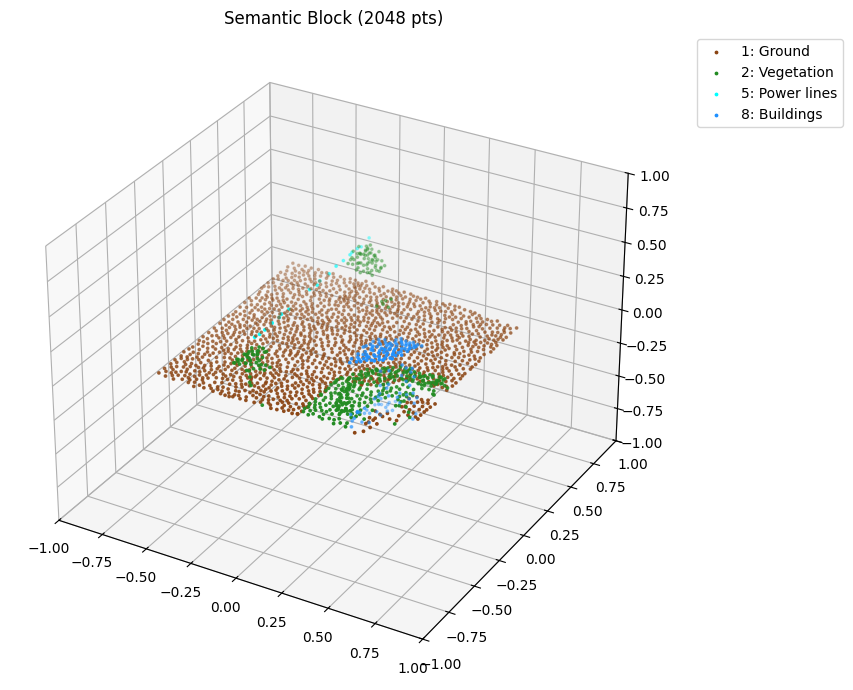

In [30]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# 8 class chuẩn của DALES (1-8)
DALES_CLASSES = {
    1: ("Ground",      "#8B4513"),
    2: ("Vegetation",  "#228B22"),
    3: ("Cars",        "#FF0000"),
    4: ("Trucks",      "#FFA500"),
    5: ("Power lines", "#00FFFF"),
    6: ("Fences",      "#FF00FF"),
    7: ("Poles",       "#FFFF00"),
    8: ("Buildings",   "#1E90FF"),
}

def inspect_npy(file_path):
    print(f"\n{'═'*65}")
    print(f"📄 FILE: {file_path}")
    print(f"{'═'*65}")

    if not os.path.exists(file_path):
        print("❌ File không tồn tại! Hãy kiểm tra lại đường dẫn.")
        return

    # Đọc file npy (dictionary được lưu bằng allow_pickle)
    raw = np.load(file_path, allow_pickle=True)
    data = raw.item() if raw.ndim == 0 else raw

    if not isinstance(data, dict):
        print(f"Shape: {data.shape}, Dtype: {data.dtype}")
        print(f"Range: [{data.min():.3f}, {data.max():.3f}]")
        return

    # In tất cả các trường dữ liệu
    for k, v in data.items():
        if isinstance(v, np.ndarray):
            print(f"  🔹 Key '{k}': shape={v.shape} | dtype={v.dtype} | min={v.min():.3f} | max={v.max():.3f}")
        else:
            print(f"  🔹 Key '{k}': {v}")

    # 1. TRƯỜNG HỢP: File POINTR (gồm partial + complete)
    if 'partial' in data and 'complete' in data:
        part = data['partial']
        comp = data['complete']
        strat = data.get('strategy', 'N/A')

        fig = plt.figure(figsize=(13, 6))
        # Partial
        ax1 = fig.add_subplot(121, projection='3d')
        ax1.scatter(part[:, 0], part[:, 1], part[:, 2], s=2, c='red')
        ax1.set_title(f"Partial ({len(part)} pts) - Strategy {strat}")
        ax1.set_xlim([-1, 1]); ax1.set_ylim([-1, 1]); ax1.set_zlim([-1, 1])

        # Complete
        ax2 = fig.add_subplot(122, projection='3d')
        ax2.scatter(comp[:, 0], comp[:, 1], comp[:, 2], s=1, c='royalblue', alpha=0.6)
        ax2.set_title(f"Complete GT ({len(comp)} pts)")
        ax2.set_xlim([-1, 1]); ax2.set_ylim([-1, 1]); ax2.set_zlim([-1, 1])

        plt.tight_layout()
        plt.show()

    # 2. TRƯỜNG HỢP: File SEMANTIC (gồm points + labels)
    elif 'points' in data and 'labels' in data:
        pts = data['points']
        lbls = data['labels']
        unique, counts = np.unique(lbls, return_counts=True)

        print("\n📊 Phân bố các class trong block:")
        for u, c in zip(unique, counts):
            name, _ = DALES_CLASSES.get(u, ("Unknown", "#888888"))
            print(f"   Class {u} ({name:12s}): {c:>5} pts ({c/len(lbls)*100:5.1f}%)")

        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection='3d')
        for u in unique:
            name, color = DALES_CLASSES.get(u, (f"Class {u}", "#888888"))
            mask = (lbls == u)
            ax.scatter(pts[mask, 0], pts[mask, 1], pts[mask, 2], s=3, c=color, label=f"{u}: {name}")
        ax.set_title(f"Semantic Block ({len(pts)} pts)")
        ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1]); ax.set_zlim([-1, 1])
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

# ═══════════════════════════════════════════════════════════════════
# CÁCH DÙNG:
# ═══════════════════════════════════════════════════════════════════
# Cách A: Tự động tìm và xem file đầu tiên tạo từ Cell 10 (test_output)
test_files = glob.glob(r"D:\AIP\data_processed\semantic_test\test_run\5080_54435_sem_0000.npy", recursive=True)
if test_files:
    inspect_npy(test_files[0])
else:
    # Cách B: Hoặc điền trực tiếp đường dẫn file bạn muốn xem vào đây:
    # inspect_npy(r"D:\AIP\data_processed\pointr\train\5080_54435_pair_0000.npy")
    # inspect_npy(r"D:\AIP\data_processed\semantic\train\5080_54435_sem_0000.npy")
    print("Chưa có file trong test_output. Bạn hãy chạy Cell 10 trước hoặc gán đường dẫn file npy cụ thể.")


## Cell 12 — Full Pipeline

Chạy toàn bộ 40 tile (23 train + 6 val + 11 test).

### Output

```
data_processed/
├── pointr/
│   ├── train/   ← {partial (2048,3), complete (8192,3), metadata}
│   ├── val/
│   └── test/
└── semantic/
    ├── train/   ← {points (2048,3), labels (2048,) [1-8], metadata}
    ├── val/
    └── test/
```

### Loader ví dụ

```python
# PoinTr
sample = np.load(path, allow_pickle=True).item()
partial  = torch.from_numpy(sample['partial'])    # (2048, 3)
complete = torch.from_numpy(sample['complete'])   # (8192, 3)

# Semantic
sample = np.load(path, allow_pickle=True).item()
points = torch.from_numpy(sample['points'])    # (2048, 3)
labels = torch.from_numpy(sample['labels']) - 1  # (2048,) → 0..7
```

In [ ]:
np.random.seed(42)

print("═" * 60)
print("  FULL PIPELINE — DALES v4")
print("═" * 60)

total_p, total_s = 0, 0

for split_name, tile_paths in splits.items():
    print(f"\n{'═' * 60}")
    print(f"  {split_name.upper()} ({len(tile_paths)} tiles)")
    print(f"{'═' * 60}")

    for p in tile_paths:
        a, b = process_tile(p, split_name, POINTR_OUT, SEMANTIC_OUT)
        total_p += a
        total_s += b

print(f"\n{'═' * 60}")
print(f"  DONE!")
print(f"  PoinTr pairs:     {total_p:,}")
print(f"  Semantic samples: {total_s:,}")
print(f"  Output: {OUTPUT_ROOT}")
print(f"{'═' * 60}")